# Sobol cube — common-random-number analysis

This notebook exploits the structural property the Sobol cube uniquely has — the **same 1111
CV halos under the same per-halo flow-matching noise** observed across **256 distinct
feedback designs** — to answer five questions that *only* the CRN cube can answer:

1. **D1.** Does each individual halo trace an approximately one-dimensional curve in money-plot
   space as feedback varies, and is that curve the same direction for every halo?
2. **D4.** Is $(f_{\rm gas}, M)$ a *sufficient statistic* for matter-power suppression — i.e.,
   do all other 30 knobs act through $f_{\rm gas}$, or is there an orthogonal direction?
3. **D5.** Does the dominant feedback direction depend on halo mass — and how does effective
   feedback dimensionality vary from groups to clusters?
4. **D3.** Which observable *pairs* (Y, T, S, P, $f_{\rm gas}$, suppression) have
   feedback-invariant joint distributions? — i.e., which scaling relations are immune to
   feedback uncertainty.
5. **D2.** What fraction of the money-plot scatter $\sigma_{\rm int}\!\approx\!0.086$ is **halo
   identity** vs **feedback choice** vs **interaction/noise**? — the decomposition that tells
   WL pipelines how much $\sigma$ collapses if feedback is pinned down.

The companion notebook `tsz_ss_calibration_sobol.ipynb` does the feedback-marginalised
population calibration; *this* notebook does the structural analysis that the CRNs enable.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz')
if not CUBE.exists():
    CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv_dev/cube.npz')
print('Reading', CUBE)
z = np.load(CUBE, allow_pickle=True)
OBS = z['obs'].astype(float)              # (n_design, n_halo, n_obs)
OBS_NAMES = list(z['obs_names'])
logM = np.log10(z['M200'].astype(float))
design_norm = z['design_norm']
astro_names = list(z['astro_names'])
n_design, n_halo, n_obs = OBS.shape
print(f'designs={n_design}  halos={n_halo}  obs={OBS_NAMES}')

SHORT = {'WindEnergyIn1e51erg': 'A_SN1', 'VariableWindVelFactor': 'A_SN2',
         'RadioFeedbackFactor': 'A_AGN1', 'RadioFeedbackReiorientationFactor': 'A_AGN2'}
PLAB = [SHORT.get(n, n) for n in astro_names]

iY  = OBS_NAMES.index('Y200')
iFG = OBS_NAMES.index('f_gas')
iSp = OBS_NAMES.index('supp_prof')
iSk = OBS_NAMES.index('supp_k10')
iT  = OBS_NAMES.index('T')
iS  = OBS_NAMES.index('S')
iP  = OBS_NAMES.index('P')

# Per-design Y-M amplitude (SS normalisation), then Delta_SS per (design, halo)
with np.errstate(invalid='ignore', divide='ignore'):
    lY = np.log10(np.where(OBS[..., iY] > 0, OBS[..., iY], np.nan))    # (d, i)
logc0_d = np.nanmean(lY - (5/3) * logM[None, :], axis=1)               # (d,)
DSS = lY - (logc0_d[:, None] + (5/3) * logM[None, :])                  # (d, i)
print(f'per-design logc0  range [{np.nanmin(logc0_d):+.3f}, {np.nanmax(logc0_d):+.3f}]')

FIG = Path('sobol_cube_figs'); FIG.mkdir(exist_ok=True)
def savefig(fig, name):
    for e in ('pdf', 'png'):
        fig.savefig(FIG / f'{name}.{e}')
    print('wrote', FIG / f'{name}.png')


Reading /mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz
designs=256  halos=1111  obs=['Y200', 'T', 'S', 'P', 'f_gas', 'm_gen', 'supp_k10', 'supp_prof']
per-design logc0  range [-29.495, -28.941]


## D1 — Per-halo trajectories in money-plot space

With CRNs locked, each halo $i$ traces a **256-point curve** in $(Y_i/Y_i^{\rm SS},\ S_i)$ as
feedback varies. We ask:
- **How 1-D is each curve?** — fraction of variance captured by its first principal direction.
- **Do all halos share the same direction?** — distribution of principal slopes.

If the curves are 1-D and parallel, "feedback" is *locally* a one-parameter family in
money-plot space, which is the cleanest possible justification for the population money-plot
framing — every halo is being pushed along the same direction by feedback.


kept 1111 / 1111 halos
PC1 variance fraction:  median 0.973   p16=0.825  p84=0.996
principal slope dS/d(Y/Y_SS):  median +0.132   IQR [-0.122, +0.392]
rms feedback displacement in money-plot space:  median 0.115
wrote sobol_cube_figs/D1_per_halo_trajectories.png


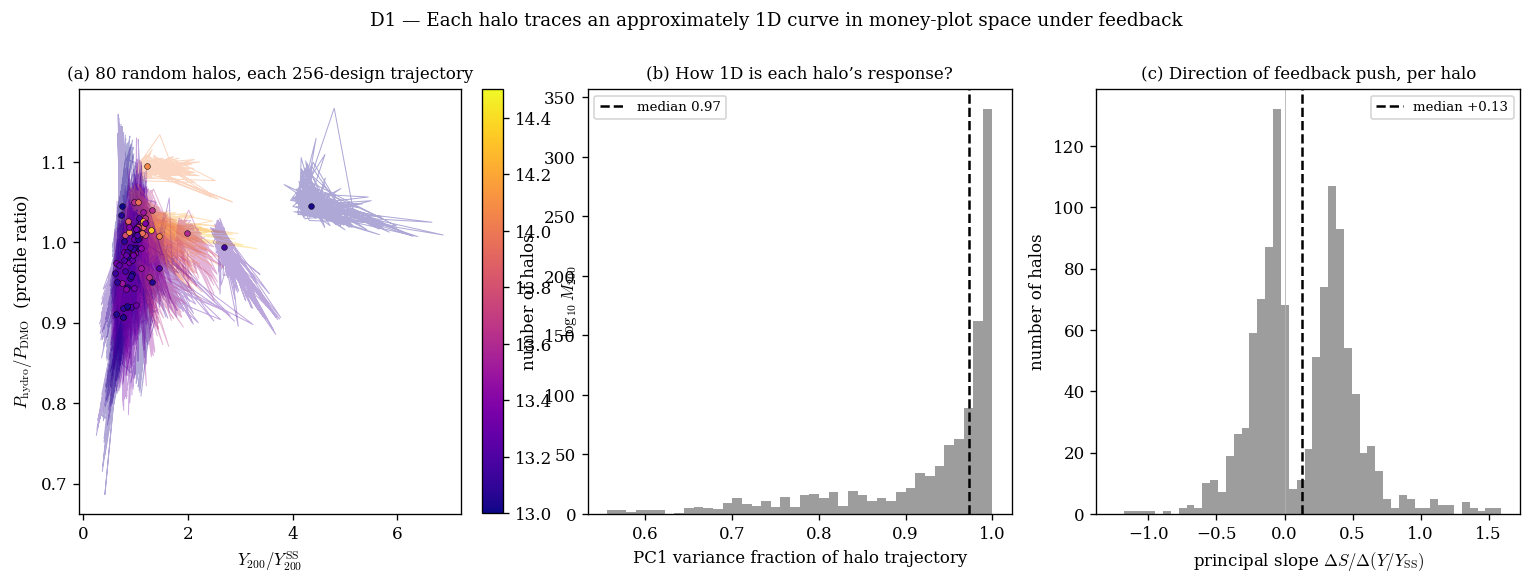

In [2]:
# Per-halo (256-point) trajectory in (Y/Y_SS, supp_prof). PCA on the centred curve gives:
#   - PC1 variance fraction  (= "how 1D is this halo's response?")
#   - principal direction    (= slope dS / d(Y/Y_SS) along feedback)
#   - rms displacement       (= "how far does the halo move under feedback?")
x_traj = 10 ** DSS                       # (d, i)  Y/Y_SS
y_traj = OBS[..., iSp]                   # (d, i)  P_hydro/P_DMO profile
xc = x_traj - np.nanmedian(x_traj, axis=0, keepdims=True)
yc = y_traj - np.nanmedian(y_traj, axis=0, keepdims=True)

keep = np.isfinite(x_traj).all(axis=0) & np.isfinite(y_traj).all(axis=0)
pc1_frac = np.full(n_halo, np.nan)
slope1   = np.full(n_halo, np.nan)
arc      = np.full(n_halo, np.nan)
for i in np.where(keep)[0]:
    M = np.column_stack([xc[:, i], yc[:, i]])
    _, sv, vt = np.linalg.svd(M, full_matrices=False)
    v = vt[0]
    pc1_frac[i] = sv[0] ** 2 / np.sum(sv ** 2)
    if abs(v[0]) > 1e-9:
        slope1[i] = v[1] / v[0]
    arc[i] = np.sqrt(np.mean(np.sum(M ** 2, axis=1)))

print(f'kept {int(keep.sum())} / {n_halo} halos')
print(f'PC1 variance fraction:  median {np.nanmedian(pc1_frac):.3f}   '
      f'p16={np.nanpercentile(pc1_frac,16):.3f}  p84={np.nanpercentile(pc1_frac,84):.3f}')
sl = slope1[np.isfinite(slope1)]
print(f'principal slope dS/d(Y/Y_SS):  median {np.nanmedian(sl):+.3f}   '
      f'IQR [{np.nanpercentile(sl,25):+.3f}, {np.nanpercentile(sl,75):+.3f}]')
print(f'rms feedback displacement in money-plot space:  median {np.nanmedian(arc):.3f}')

# Figure
rng = np.random.default_rng(0)
sel = rng.choice(np.where(keep)[0], size=80, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

ax = axes[0]
norm = plt.Normalize(13, 14.5)
for i in sel:
    c = plt.cm.plasma(norm(logM[i]))
    ax.plot(x_traj[:, i], y_traj[:, i], color=c, alpha=0.35, lw=0.6)
    ax.scatter(np.nanmedian(x_traj[:, i]), np.nanmedian(y_traj[:, i]),
               s=12, color=c, edgecolor='k', lw=0.3, zorder=3)
ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$  (profile ratio)')
ax.set_title('(a) 80 random halos, each 256-design trajectory', fontsize=10)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='plasma'), ax=ax,
             fraction=0.05, label=r'$\log_{10}M_{200}$')

ax = axes[1]
ax.hist(pc1_frac[np.isfinite(pc1_frac)], bins=40, color='0.55', alpha=0.85)
ax.axvline(np.nanmedian(pc1_frac), color='k', ls='--',
           label=f'median {np.nanmedian(pc1_frac):.2f}')
ax.set_xlabel('PC1 variance fraction of halo trajectory')
ax.set_ylabel('number of halos')
ax.set_title('(b) How 1D is each halo\u2019s response?', fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
lo, hi = np.nanpercentile(sl, [1, 99])
bins = np.linspace(lo, hi, 50)
ax.hist(sl, bins=bins, color='0.55', alpha=0.85)
ax.axvline(np.nanmedian(sl), color='k', ls='--', label=f'median {np.nanmedian(sl):+.2f}')
ax.axvline(0, color='0.7', lw=0.5)
ax.set_xlabel(r'principal slope $\Delta S / \Delta(Y/Y_{\rm SS})$')
ax.set_ylabel('number of halos')
ax.set_title('(c) Direction of feedback push, per halo', fontsize=10)
ax.legend(fontsize=8)

fig.suptitle('D1 — Each halo traces an approximately 1D curve in money-plot space under feedback',
             y=1.02, fontsize=11)
savefig(fig, 'D1_per_halo_trajectories'); plt.show()


### D1 deeper — What sets the per-halo feedback direction?

D1 said each halo is ~1D (median PC1 frac 0.97) **but** the principal-slope histogram is
broad with at least two modes — halos do not all share the same feedback direction. Three
things to nail down:

1. **What physical halo property predicts the slope?** Correlate `slope1` with mass,
   median $f_{\rm gas}$, $Y_i^{\rm SS}$-residual, arc length, and assembly features
   (`c_V`, $\lambda$, $z_{\rm form}$, $r_{\rm half}$ from `assembly_table.npz`).
2. **Identify the cluster at $Y/Y_{\rm SS}\!\sim\!4$–6** in panel (a) — these are
   low-mass halos with anomalously large $Y$, and they sit in their own pocket of
   money-plot space.
3. **Per-mass-bin trajectory overlay** — replace the unreadable 80-trajectory plot
   with one panel per mass bin so we can *see* whether the slope changes with mass.


loaded assembly features (1111, 5)  ['c_V', 'lambda', 'veldisp', 'rhalf', 'z_form']

Spearman(per-halo slope1 vs covariate):
  logM                       rho = -0.487   (n=1111)
  median f_gas               rho = -0.515   (n=1111)
  median Y/Y_SS              rho = -0.468   (n=1111)
  arc (rms displacement)     rho = -0.162   (n=1111)
  median S                   rho = -0.428   (n=1111)
  c_V                        rho = +0.201   (n=1111)
  lambda                     rho = -0.109   (n=1111)
  veldisp                    rho = -0.459   (n=1111)
  rhalf                      rho = -0.240   (n=1111)
  z_form                     rho = +0.163   (n=1111)

High Y/Y_SS outliers (median Y/Y_SS > 2): n=36
  their logM:      13.25  [p16 13.06, p84 13.50]
  their f_gas:     0.136
  their slope1:    -0.032
  full sample slope median: +0.193  (excluding outliers)
wrote sobol_cube_figs/D1deeper_slope_drivers.png


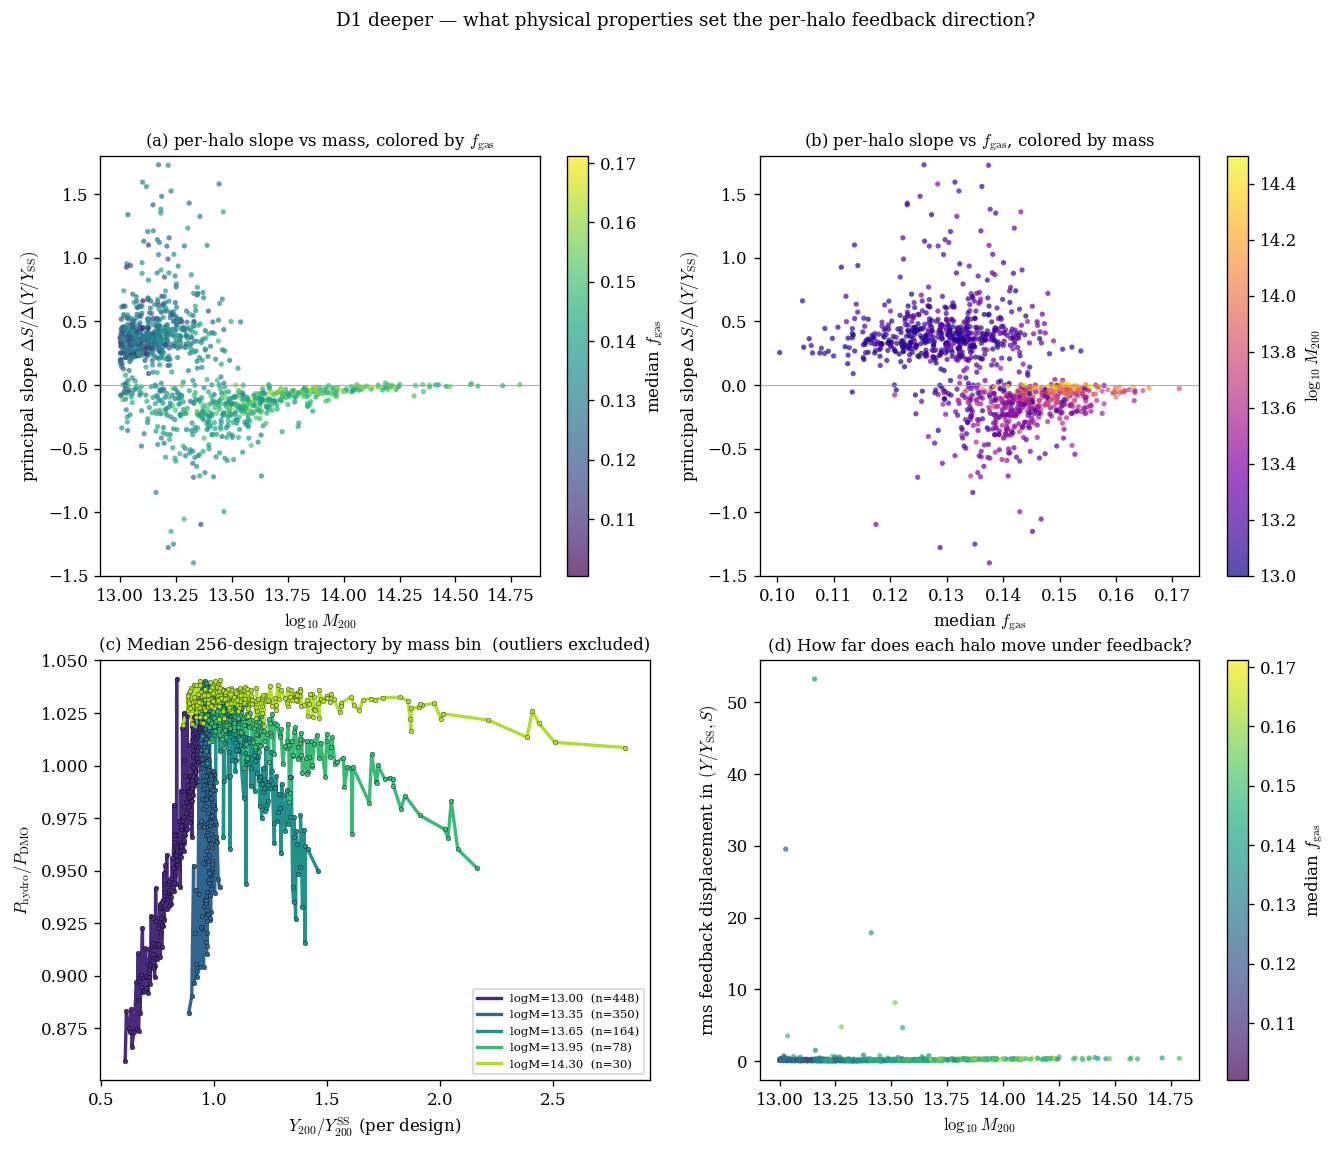

In [7]:
# --- per-halo covariates ---------------------------------------------------
fg_med   = np.nanmedian(OBS[..., iFG], axis=0)          # (i,) median f_gas across designs
YYss_med = np.nanmedian(x_traj,        axis=0)          # (i,) median Y/Y_SS across designs
S_med    = np.nanmedian(y_traj,        axis=0)          # (i,) median suppression

ASM = Path('/mnt/home/mlee1/ceph/sobol_ss_cv/assembly_table.npz')
asm_feats, asm_names = None, []
if ASM.exists():
    A = np.load(ASM, allow_pickle=True)
    asm_feats = A['feats'].astype(float) if 'feats' in A.files else None
    asm_names = list(A['feat_names']) if 'feat_names' in A.files else []
    print(f'loaded assembly features {asm_feats.shape if asm_feats is not None else None}  {asm_names}')

# --- correlations slope ~ covariate ----------------------------------------
covs = {'logM': logM, 'median f_gas': fg_med, 'median Y/Y_SS': YYss_med,
        'arc (rms displacement)': arc, 'median S': S_med}
if asm_feats is not None:
    for j, n in enumerate(asm_names):
        covs[n] = asm_feats[:, j]

print('\nSpearman(per-halo slope1 vs covariate):')
fin = np.isfinite(slope1)
rows = []
for name, c in covs.items():
    m = fin & np.isfinite(c)
    if m.sum() < 50:
        continue
    r = spearmanr(c[m], slope1[m]).correlation
    rows.append((name, r))
    print(f'  {name:25s}  rho = {r:+.3f}   (n={int(m.sum())})')

# --- identify the high Y/Y_SS outliers -------------------------------------
hi = YYss_med > 2.0
print(f'\nHigh Y/Y_SS outliers (median Y/Y_SS > 2): n={int(hi.sum())}')
if hi.sum():
    print(f'  their logM:      {np.nanmedian(logM[hi]):.2f}  '
          f'[p16 {np.nanpercentile(logM[hi],16):.2f}, p84 {np.nanpercentile(logM[hi],84):.2f}]')
    print(f'  their f_gas:     {np.nanmedian(fg_med[hi]):.3f}')
    print(f'  their slope1:    {np.nanmedian(slope1[hi]):+.3f}')
    print(f'  full sample slope median: {np.nanmedian(slope1[fin & ~hi]):+.3f}  (excluding outliers)')

# --- figure ----------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) slope vs logM colored by f_gas
ax = axes[0, 0]
sc = ax.scatter(logM[fin], slope1[fin], c=fg_med[fin], s=10, cmap='viridis',
                alpha=0.7, edgecolor='none')
ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel(r'principal slope $\Delta S/\Delta(Y/Y_{\rm SS})$')
ax.set_ylim(-1.5, 1.8)
plt.colorbar(sc, ax=ax, label=r'median $f_{\rm gas}$')
ax.set_title(r'(a) per-halo slope vs mass, colored by $f_{\rm gas}$', fontsize=10)

# (b) slope vs median f_gas colored by logM
ax = axes[0, 1]
sc = ax.scatter(fg_med[fin], slope1[fin], c=logM[fin], s=10, cmap='plasma',
                alpha=0.7, edgecolor='none', vmin=13, vmax=14.5)
ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel(r'median $f_{\rm gas}$')
ax.set_ylabel(r'principal slope $\Delta S/\Delta(Y/Y_{\rm SS})$')
ax.set_ylim(-1.5, 1.8)
plt.colorbar(sc, ax=ax, label=r'$\log_{10} M_{200}$')
ax.set_title(r'(b) per-halo slope vs $f_{\rm gas}$, colored by mass', fontsize=10)

# (c) per-mass-bin trajectory overlay (one panel) -- use 2D density of all halo points
ax = axes[1, 0]
mass_edges_d = np.array([12.8, 13.2, 13.5, 13.8, 14.1, 14.5])
mass_ctrs_d  = 0.5 * (mass_edges_d[:-1] + mass_edges_d[1:])
cmap_m = plt.cm.viridis
norm_m = plt.Normalize(mass_edges_d[0], mass_edges_d[-1])
for k in range(len(mass_ctrs_d)):
    sb = (logM >= mass_edges_d[k]) & (logM < mass_edges_d[k+1]) & keep & ~hi
    if sb.sum() < 5:
        continue
    # median trajectory across halos in this bin: at each design d, median over halos
    x_med = np.nanmedian(x_traj[:, sb], axis=1)        # (d,)
    y_med = np.nanmedian(y_traj[:, sb], axis=1)
    # sort by x for a clean curve
    order_x = np.argsort(x_med)
    ax.plot(x_med[order_x], y_med[order_x], color=cmap_m(norm_m(mass_ctrs_d[k])),
            lw=2.0, label=f'logM={mass_ctrs_d[k]:.2f}  (n={int(sb.sum())})')
    ax.scatter(x_med, y_med, s=8, color=cmap_m(norm_m(mass_ctrs_d[k])),
               edgecolor='k', lw=0.2, zorder=3)
ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$ (per design)')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$')
ax.legend(fontsize=7, loc='best')
ax.set_title('(c) Median 256-design trajectory by mass bin  (outliers excluded)', fontsize=10)

# (d) arc length (rms feedback displacement) vs logM, colored by f_gas
ax = axes[1, 1]
sc = ax.scatter(logM[fin], arc[fin], c=fg_med[fin], s=10, cmap='viridis',
                alpha=0.7, edgecolor='none')
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel(r'rms feedback displacement in $(Y/Y_{\rm SS}, S)$')
plt.colorbar(sc, ax=ax, label=r'median $f_{\rm gas}$')
ax.set_title(r'(d) How far does each halo move under feedback?', fontsize=10)

fig.suptitle('D1 deeper — what physical properties set the per-halo feedback direction?',
             y=1.00, fontsize=11)
savefig(fig, 'D1deeper_slope_drivers'); plt.show()


### D1 deeper-II — slope flip (A), partial correlations (B), sign-split trajectories (C)

- **A.** Per-mass-bin median slope ± bootstrap CI, with the zero-crossing mass $M_\star$ at
  which the average feedback push in money-plot space changes sign.
- **B.** Partial Spearman to disentangle the highly correlated drivers $f_{\rm gas}$ and
  $\log M$: report $\rho(slope,X\,|\,Y)$ to see which is the *causal* slope driver. Also
  include $c_V$ and $z_{\rm form}$ to see if assembly history adds an independent handle.
- **C.** Visual proof: redraw 80-halo trajectories split by ${\rm sign}(slope_1)$ — does the
  positive-slope subsample trace a coherent up-right arc and the negative-slope subsample
  a down-left arc?


A. linear fit: slope(logM) = -0.351 * logM + +4.783
A. zero-crossing mass:  logM* = 13.64  (M* = 4.39e+13 Msun/h)

B. Marginal vs partial Spearman of slope1 vs each driver (high-Y/Y_SS excluded):
   n=1075
   driver         rho_marg   rho|others
   logM             -0.488       -0.200
   f_gas            -0.514       -0.286
   c_V              +0.198       +0.069
   z_form           +0.163       +0.032
   (sanity: rho(logM, f_gas) = +0.682)

C. positive-slope halos: n=563,  median logM=13.14,  median f_gas=0.130
   negative-slope halos: n=406,  median logM=13.48,  median f_gas=0.143
wrote sobol_cube_figs/D1deeperII_slopeflip_partial.png


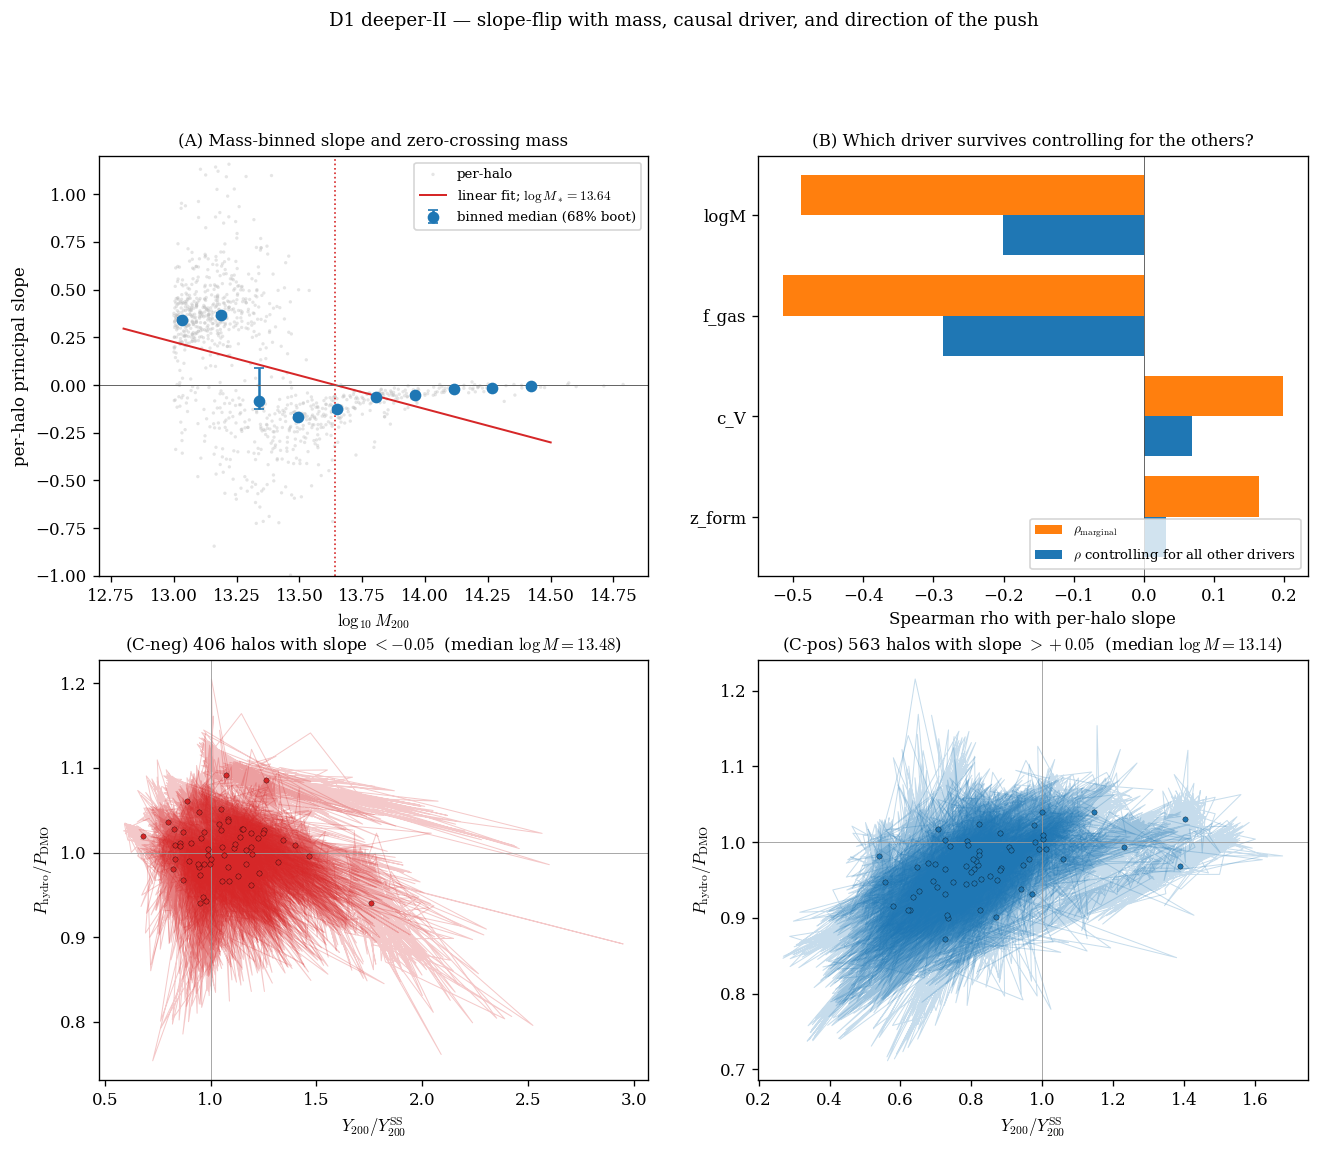

In [8]:
from scipy.stats import rankdata

# ---------- A. Mass-binned slope with bootstrap CI ------------------------
edges_a = np.linspace(12.8, 14.5, 12)
ctrs_a  = 0.5 * (edges_a[:-1] + edges_a[1:])
B = 400
rng = np.random.default_rng(1)
fin_xc = fin & ~hi                                # exclude high-Y/Y_SS outliers
med_b   = np.full(len(ctrs_a), np.nan)
lo_b    = np.full(len(ctrs_a), np.nan)
hi_b    = np.full(len(ctrs_a), np.nan)
n_bins  = np.zeros(len(ctrs_a), int)
for k in range(len(ctrs_a)):
    sb = fin_xc & (logM >= edges_a[k]) & (logM < edges_a[k+1])
    n_bins[k] = int(sb.sum())
    if n_bins[k] < 8:
        continue
    s_vals = slope1[sb]
    med_b[k] = np.median(s_vals)
    boot = np.array([np.median(rng.choice(s_vals, size=len(s_vals), replace=True))
                     for _ in range(B)])
    lo_b[k], hi_b[k] = np.percentile(boot, [16, 84])

# Linear fit to find zero-crossing mass
ok_fit = np.isfinite(med_b) & (n_bins >= 20)
if ok_fit.sum() >= 3:
    a_fit, b_fit = np.polyfit(ctrs_a[ok_fit], med_b[ok_fit], 1)
    M_star = -b_fit / a_fit if abs(a_fit) > 1e-6 else np.nan
else:
    a_fit, b_fit, M_star = np.nan, np.nan, np.nan
print(f'A. linear fit: slope(logM) = {a_fit:+.3f} * logM + {b_fit:+.3f}')
print(f'A. zero-crossing mass:  logM* = {M_star:.2f}  (M* = {10**M_star:.2e} Msun/h)')

# ---------- B. Partial Spearman (controlling for one or several covariates) -
def partial_spearman(x, y, Zcols):
    """Return rho(x, y | Z) via rank-residual Pearson."""
    Zr = np.column_stack([rankdata(c) for c in Zcols])
    Zr = np.column_stack([Zr, np.ones(len(x))])
    bx, *_ = np.linalg.lstsq(Zr, rankdata(x), rcond=None)
    by, *_ = np.linalg.lstsq(Zr, rankdata(y), rcond=None)
    return float(np.corrcoef(rankdata(x) - Zr @ bx,
                             rankdata(y) - Zr @ by)[0, 1])

ok_b = fin_xc & np.all(np.isfinite([logM, fg_med, S_med, YYss_med]), axis=0)
if asm_feats is not None:
    ok_b &= np.all(np.isfinite(asm_feats), axis=1)

X_dict = {'logM': logM, 'f_gas': fg_med}
if asm_feats is not None:
    for j, nm in enumerate(asm_names):
        if nm in ('c_V', 'z_form'):
            X_dict[nm] = asm_feats[:, j]

print('\nB. Marginal vs partial Spearman of slope1 vs each driver (high-Y/Y_SS excluded):')
print(f'   n={int(ok_b.sum())}')
print(f'   {"driver":12s} {"rho_marg":>10s}  {"rho|others":>11s}')
for nm, x in X_dict.items():
    rho_marg = spearmanr(x[ok_b], slope1[ok_b]).correlation
    others = [v[ok_b] for k_, v in X_dict.items() if k_ != nm]
    rho_part = partial_spearman(x[ok_b], slope1[ok_b], others)
    print(f'   {nm:12s} {rho_marg:+10.3f}  {rho_part:+11.3f}')

# Cross-check: how correlated are logM and f_gas with each other?
rho_mf = spearmanr(logM[ok_b], fg_med[ok_b]).correlation
print(f'   (sanity: rho(logM, f_gas) = {rho_mf:+.3f})')

# ---------- C. Trajectory split by sign(slope1) ----------------------------
pos = fin_xc & (slope1 >  0.05)
neg = fin_xc & (slope1 < -0.05)
print(f'\nC. positive-slope halos: n={int(pos.sum())},  '
      f'median logM={np.median(logM[pos]):.2f},  median f_gas={np.median(fg_med[pos]):.3f}')
print(f'   negative-slope halos: n={int(neg.sum())},  '
      f'median logM={np.median(logM[neg]):.2f},  median f_gas={np.median(fg_med[neg]):.3f}')

n_show = 60
ipos = rng.choice(np.where(pos)[0], size=min(n_show, int(pos.sum())), replace=False)
ineg = rng.choice(np.where(neg)[0], size=min(n_show, int(neg.sum())), replace=False)

# ---------- Figure --------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (A) slope vs mass with bootstrap + zero-crossing
ax = axes[0, 0]
ax.scatter(logM[fin_xc], slope1[fin_xc], s=4, color='0.75', alpha=0.4, edgecolor='none',
           label='per-halo')
ax.errorbar(ctrs_a, med_b, yerr=[med_b - lo_b, hi_b - med_b],
            fmt='o', color='tab:blue', lw=1.5, capsize=3, label='binned median (68% boot)')
xx = np.linspace(12.8, 14.5, 50)
ax.plot(xx, a_fit * xx + b_fit, color='tab:red', lw=1.2,
        label=f'linear fit; $\\log M_*={M_star:.2f}$')
ax.axhline(0, color='0.4', lw=0.6)
if np.isfinite(M_star):
    ax.axvline(M_star, color='tab:red', ls=':', lw=1.0)
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel('per-halo principal slope')
ax.set_ylim(-1.0, 1.2)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('(A) Mass-binned slope and zero-crossing mass', fontsize=10)

# (B) marginal vs partial Spearman bar
ax = axes[0, 1]
drivers, rho_m, rho_p = [], [], []
for nm, x in X_dict.items():
    drivers.append(nm)
    rho_m.append(spearmanr(x[ok_b], slope1[ok_b]).correlation)
    others = [v[ok_b] for k_, v in X_dict.items() if k_ != nm]
    rho_p.append(partial_spearman(x[ok_b], slope1[ok_b], others))
y_pos = np.arange(len(drivers))
w = 0.4
ax.barh(y_pos - w/2, rho_m, height=w, color='tab:orange',
        label=r'$\rho_{\rm marginal}$')
ax.barh(y_pos + w/2, rho_p, height=w, color='tab:blue',
        label=r'$\rho$ controlling for all other drivers')
ax.axvline(0, color='0.3', lw=0.5)
ax.set_yticks(y_pos); ax.set_yticklabels(drivers)
ax.invert_yaxis()
ax.set_xlabel('Spearman rho with per-halo slope')
ax.legend(fontsize=8, loc='lower right')
ax.set_title(r'(B) Which driver survives controlling for the others?', fontsize=10)

# (C) trajectory: negative-slope halos
ax = axes[1, 0]
for i in ineg:
    ax.plot(x_traj[:, i], y_traj[:, i], color='tab:red', alpha=0.25, lw=0.6)
    ax.scatter(np.nanmedian(x_traj[:, i]), np.nanmedian(y_traj[:, i]),
               s=10, color='tab:red', edgecolor='k', lw=0.2, zorder=3)
ax.axhline(1, color='0.6', lw=0.5); ax.axvline(1, color='0.6', lw=0.5)
ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$')
ax.set_title(f'(C-neg) {int(neg.sum())} halos with slope $< -0.05$  '
             rf'(median $\log M={np.median(logM[neg]):.2f}$)', fontsize=10)

# (C) trajectory: positive-slope halos
ax = axes[1, 1]
for i in ipos:
    ax.plot(x_traj[:, i], y_traj[:, i], color='tab:blue', alpha=0.25, lw=0.6)
    ax.scatter(np.nanmedian(x_traj[:, i]), np.nanmedian(y_traj[:, i]),
               s=10, color='tab:blue', edgecolor='k', lw=0.2, zorder=3)
ax.axhline(1, color='0.6', lw=0.5); ax.axvline(1, color='0.6', lw=0.5)
ax.set_xlabel(r'$Y_{200}/Y_{200}^{\rm SS}$')
ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$')
ax.set_title(f'(C-pos) {int(pos.sum())} halos with slope $> +0.05$  '
             rf'(median $\log M={np.median(logM[pos]):.2f}$)', fontsize=10)

fig.suptitle('D1 deeper-II — slope-flip with mass, causal driver, and direction of the push',
             y=1.00, fontsize=11)
savefig(fig, 'D1deeperII_slopeflip_partial'); plt.show()


### D1 deeper-III — f_gas is a cylindrical column, not a halo R200 sphere

`sobol_ss_generation.reduce_design()`:

```python
ap = _RR <= r200_pix                # 2D circular aperture, radius R200 in pixels
tot = g[0] + g[1] + g[2]            # DM_hydro + Gas + Stars  (projected through 6.25 Mpc/h)
gas = g[1]
obs[i, 4] = gas[ap].sum() / tot[ap].sum()
```

The patch is 6.25 Mpc/h × 6.25 Mpc/h × 6.25 Mpc/h projected to 2D, so the f_gas aperture is a
**cylinder of radius $R_{200}$ and depth 6.25 Mpc/h**, not a 3D $R_{200}$ sphere. For a
$10^{13.5}$ halo $R_{200}\!\approx\!500$ kpc/h, the cylinder is $\sim$12 × deeper than the
halo diameter, so AGN-ejected gas that goes to $2\!-\!3\,R_{200}$ along the LOS is
**re-included** in both the numerator and the denominator. The cylinder approximately
conserves baryons, so $f_{\rm gas}^{\rm cube}$ collapses toward cosmic $\Omega_b/\Omega_m$.

This invalidates the "$f_{\rm gas}$ is the causal driver" conclusion from D1-deeper-II.B —
the partial Spearman was picking up a quantity dominated by LOS contamination. Let's
check:

1. What is the cube `f_gas` distribution, and how does it sit relative to the cosmic
   baryon fraction?
2. How much does feedback actually move the cube `f_gas` per halo? (the part of the
   signal that *is* meaningful — feedback can still push gas out of the LOS column).
3. Re-run the partial Spearman with two **uncontaminated** halo-physics proxies that
   the cube actually measures within $R_{200}$ (2D, but gas-mass-weighted, so they
   *do* track halo gas state): **entropy $S$** and **temperature $T$**.


In [ ]:
FB_COSMIC = 0.049 / 0.3019                                  # IllustrisTNG fiducial Omega_b / Omega_m
print(f'cosmic baryon fraction (TNG fiducial)  = {FB_COSMIC:.4f}')

# ---- (1) f_gas vs cosmic, full distribution -------------------------------
fg_all_pool = OBS[..., iFG].ravel()
fg_all_pool = fg_all_pool[np.isfinite(fg_all_pool)]
print(f'\ncube f_gas distribution over all (design, halo) points (N={len(fg_all_pool):,}):')
for p in (5, 16, 50, 84, 95):
    print(f'   p{p:02d} = {np.percentile(fg_all_pool, p):.4f}')
frac_above = np.mean(fg_all_pool > FB_COSMIC)
frac_within_1pct = np.mean(np.abs(fg_all_pool - FB_COSMIC) / FB_COSMIC < 0.05)
print(f'   {100*frac_above:.1f}% of points have f_gas > cosmic')
print(f'   {100*frac_within_1pct:.1f}% are within 5% of cosmic')

# ---- (2) Per-halo response amplitude (max - min across 256 designs) -------
fg_range = (np.nanmax(OBS[..., iFG], axis=0) - np.nanmin(OBS[..., iFG], axis=0))
fg_std   = np.nanstd(OBS[..., iFG], axis=0)
print(f'\nper-halo f_gas response across 256 designs:')
print(f'   median (max - min): {np.nanmedian(fg_range):.4f}   '
      f'i.e. {100 * np.nanmedian(fg_range) / FB_COSMIC:.1f}% of cosmic f_b')
print(f'   median std        : {np.nanmedian(fg_std):.4f}')

# ---- (3) Re-do partial Spearman using uncontaminated halo-physics proxies -
T_med = np.nanmedian(OBS[..., iT], axis=0)            # gas-mass-weighted, inside R200 aperture
S_ent_med = np.nanmedian(OBS[..., iS], axis=0)        # gas-mass-weighted entropy
P_med = np.nanmedian(OBS[..., iP], axis=0)

# Log-transform what's strictly positive
lT  = np.log10(np.where(T_med > 0, T_med, np.nan))
lS  = np.log10(np.where(S_ent_med > 0, S_ent_med, np.nan))
lP  = np.log10(np.where(P_med > 0, P_med, np.nan))

X_dict2 = {
    'logM'             : logM,
    'cube f_gas (LOS)' : fg_med,
    'f_gas range/cosmic': fg_range / FB_COSMIC,
    'median log T'     : lT,
    'median log S_ent' : lS,
    'median log P'     : lP,
}
ok_c = fin_xc.copy()
for v in X_dict2.values():
    ok_c &= np.isfinite(v)

print(f'\nMarginal vs partial Spearman of slope1 against each candidate driver '
      f'(n={int(ok_c.sum())}, high-Y/Y_SS outliers excluded):')
print(f'   {"driver":22s} {"rho_marg":>10s}  {"rho|others":>11s}')
rho_table = {}
for nm, x in X_dict2.items():
    rho_marg = spearmanr(x[ok_c], slope1[ok_c]).correlation
    others = [v[ok_c] for k_, v in X_dict2.items() if k_ != nm]
    rho_part = partial_spearman(x[ok_c], slope1[ok_c], others)
    rho_table[nm] = (rho_marg, rho_part)
    print(f'   {nm:22s} {rho_marg:+10.3f}  {rho_part:+11.3f}')

# How correlated are the new candidate drivers with each other?
print('\nSpearman cross-correlations among candidate drivers:')
names_list = list(X_dict2.keys())
M_cross = np.zeros((len(names_list), len(names_list)))
for i_, ni in enumerate(names_list):
    for j_, nj in enumerate(names_list):
        if i_ <= j_:
            M_cross[i_, j_] = spearmanr(X_dict2[ni][ok_c], X_dict2[nj][ok_c]).correlation
print(f'   {"":22s} ' + ' '.join(f'{n[:10]:>10s}' for n in names_list))
for i_, ni in enumerate(names_list):
    row = []
    for j_ in range(len(names_list)):
        if i_ <= j_:
            row.append(f'{M_cross[i_, j_]:+.3f}')
        else:
            row.append('        ')
    print(f'   {ni:22s} ' + ' '.join(f'{v:>10s}' for v in row))

# ---- Figure ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))

# (a) f_gas distribution with cosmic baryon fraction
ax = axes[0, 0]
ax.hist(fg_all_pool, bins=80, color='0.5', alpha=0.85, density=True)
ax.axvline(FB_COSMIC, color='tab:red', lw=2,
           label=rf'cosmic $\Omega_b/\Omega_m={FB_COSMIC:.4f}$')
ax.set_xlabel(r'cube $f_{\rm gas}$  (cylindrical R200 aperture)')
ax.set_ylabel('density')
ax.set_title(f'(a) {100*frac_within_1pct:.0f}% of points within 5% of cosmic; '
             f'{100*frac_above:.0f}% above cosmic', fontsize=10)
ax.legend(fontsize=9)

# (b) per-halo f_gas response amplitude vs mass
ax = axes[0, 1]
fin_r = np.isfinite(fg_range) & np.isfinite(logM)
sc = ax.scatter(logM[fin_r], 100 * fg_range[fin_r] / FB_COSMIC, s=8,
                c=fg_med[fin_r], cmap='viridis', alpha=0.7, edgecolor='none')
ax.set_xlabel(r'$\log_{10} M_{200}$')
ax.set_ylabel(r'per-halo $\Delta f_{\rm gas}$ (max-min) as % of cosmic')
ax.set_title(r'(b) How much does feedback move cube $f_{\rm gas}$?', fontsize=10)
plt.colorbar(sc, ax=ax, label=r'median $f_{\rm gas}$')

# (c) marginal vs partial Spearman bar (new proxies)
ax = axes[1, 0]
y_pos = np.arange(len(names_list))
w = 0.4
rho_m_arr = np.array([rho_table[n][0] for n in names_list])
rho_p_arr = np.array([rho_table[n][1] for n in names_list])
ax.barh(y_pos - w/2, rho_m_arr, height=w, color='tab:orange',
        label=r'$\rho_{\rm marginal}$')
ax.barh(y_pos + w/2, rho_p_arr, height=w, color='tab:blue',
        label=r'$\rho$ controlling for all others')
ax.axvline(0, color='0.3', lw=0.5)
ax.set_yticks(y_pos); ax.set_yticklabels(names_list, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Spearman with per-halo slope1')
ax.legend(fontsize=8, loc='lower right')
ax.set_title('(c) Partial Spearman with uncontaminated halo-physics proxies', fontsize=10)

# (d) cross-correlation heatmap
ax = axes[1, 1]
M_full = M_cross + M_cross.T - np.diag(np.diag(M_cross))
im = ax.imshow(M_full, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(names_list)))
ax.set_xticklabels(names_list, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(names_list)))
ax.set_yticklabels(names_list, fontsize=7)
for i_ in range(len(names_list)):
    for j_ in range(len(names_list)):
        ax.text(j_, i_, f'{M_full[i_, j_]:.2f}', ha='center', va='center',
                fontsize=6, color='w' if abs(M_full[i_, j_]) > 0.5 else 'k')
plt.colorbar(im, ax=ax, fraction=0.046, label='Spearman')
ax.set_title('(d) Driver cross-correlations', fontsize=10)

fig.suptitle('D1 deeper-III — cylindrical f_gas is contaminated; entropy/temperature are cleaner',
             y=1.00, fontsize=11)
savefig(fig, 'D1deeperIII_fgas_diagnostic'); plt.show()


## D4 — Is $(f_{\rm gas}, M)$ a sufficient statistic for matter suppression?

Pooling all $256\times1111$ (design, halo) points, we predict $S = P_{\rm hydro}/P_{\rm DMO}$
from $(f_{\rm gas}, \log M)$ alone using a 2-D rolling-bin fit, then ask whether the residual
$S-\hat S$ still correlates with any of the 30 feedback knobs. If it does, that knob is
**orthogonal** to $f_{\rm gas}$ in its effect on suppression — i.e., $f_{\rm gas}$ is *not* a
sufficient statistic and any 1-parameter baryonification (SP, HMcode-bary, BCM) has an
irreducible error from that direction. If not, the case for $f_{\rm gas}$ as the master
baryonic observable is closed.


pooled n = 284,416
var(S)            = 3.1625e-03   sigma = 0.0562
var(S | f_gas, M) = 1.5301e-03   sigma = 0.0391
-> (f_gas, M) explains 51.6% of var(S)

Top 5 knobs by |rho(knob, S)| -- and what survives after conditioning on (f_gas, M):
  IMFslope                        rho(S)=-0.258   rho(residual)=-0.144
  A_SN1                           rho(S)=+0.222   rho(residual)=-0.023
  BlackHoleRadiativeEfficiency    rho(S)=+0.175   rho(residual)=+0.147
  QuasarThreshold                 rho(S)=-0.130   rho(residual)=-0.110
  A_AGN2                          rho(S)=-0.106   rho(residual)=-0.040

Top 5 knobs ORTHOGONAL to f_gas (largest |rho(residual)|):
  BlackHoleRadiativeEfficiency    rho(S)=+0.175   rho(residual)=+0.147
  IMFslope                        rho(S)=-0.258   rho(residual)=-0.144
  A_SN2                           rho(S)=+0.082   rho(residual)=-0.133
  WindFreeTravelDensFac           rho(S)=+0.003   rho(residual)=+0.131
  QuasarThreshold                 rho(S)=-0.130   rho(residua

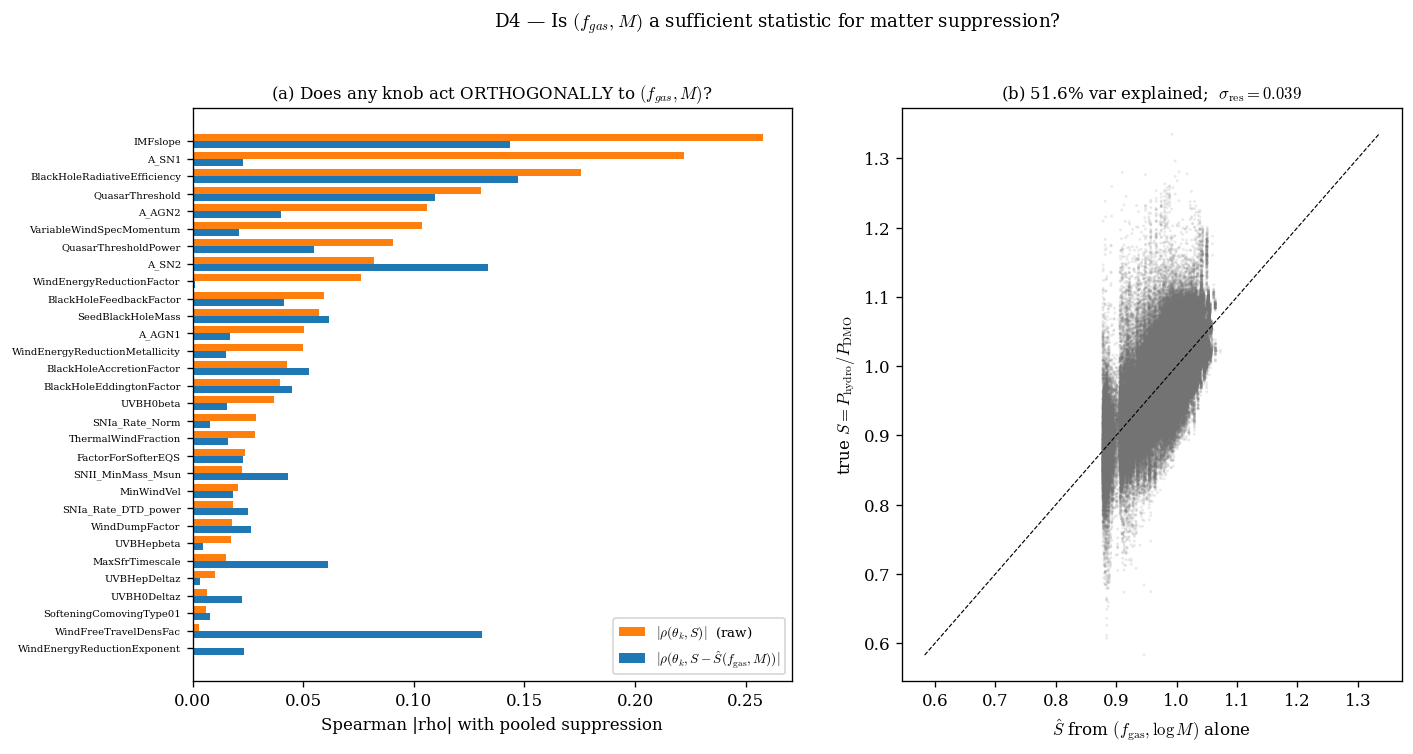

In [3]:
# Pool (design, halo) -> long vectors.  Predict S from (f_gas, logM) by binning in f_gas
# and a linear-in-logM fit per bin (handles the obvious group-vs-cluster mass trend).
fg_all  = OBS[..., iFG].ravel()
S_all   = OBS[..., iSp].ravel()
m_all   = np.tile(logM, n_design)
T_all   = np.repeat(design_norm, n_halo, axis=0)        # (d*i, 30)

ok = np.isfinite(fg_all) & np.isfinite(S_all) & np.isfinite(m_all)
fg_all, S_all, m_all, T_all = fg_all[ok], S_all[ok], m_all[ok], T_all[ok]
print(f'pooled n = {len(S_all):,}')

def cond_predict(x1, x2, y, n1=20):
    """Bin in x1; per-bin linear fit y = a*x2 + b. Returns y_hat with the same shape."""
    e1 = np.unique(np.nanpercentile(x1, np.linspace(0, 100, n1 + 1)))
    pred = np.full_like(y, np.nan)
    for k in range(len(e1) - 1):
        s = (x1 >= e1[k]) & (x1 < e1[k + 1] if k < len(e1) - 2 else x1 <= e1[k + 1])
        if s.sum() < 20:
            continue
        a, b = np.polyfit(x2[s], y[s], 1)
        pred[s] = a * x2[s] + b
    return pred

S_hat = cond_predict(fg_all, m_all, S_all)
res   = S_all - S_hat
m_fin = np.isfinite(res)

var_total = np.nanvar(S_all)
var_res   = np.nanvar(res)
print(f'var(S)            = {var_total:.4e}   sigma = {np.sqrt(var_total):.4f}')
print(f'var(S | f_gas, M) = {var_res:.4e}   sigma = {np.sqrt(var_res):.4f}')
print(f'-> (f_gas, M) explains {100 * (1 - var_res / var_total):.1f}% of var(S)')

# Per-knob: |Spearman(knob, S)|  vs  |Spearman(knob, residual)|
rho_S   = np.array([spearmanr(T_all[m_fin, k], S_all[m_fin]).correlation for k in range(len(PLAB))])
rho_res = np.array([spearmanr(T_all[m_fin, k], res[m_fin]).correlation   for k in range(len(PLAB))])

print('\nTop 5 knobs by |rho(knob, S)| -- and what survives after conditioning on (f_gas, M):')
for k in np.argsort(-np.abs(rho_S))[:5]:
    print(f'  {PLAB[k]:30s}  rho(S)={rho_S[k]:+.3f}   rho(residual)={rho_res[k]:+.3f}')
orth = np.argsort(-np.abs(rho_res))[:5]
print('\nTop 5 knobs ORTHOGONAL to f_gas (largest |rho(residual)|):')
for k in orth:
    print(f'  {PLAB[k]:30s}  rho(S)={rho_S[k]:+.3f}   rho(residual)={rho_res[k]:+.3f}')

# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2),
                         gridspec_kw={'width_ratios': [1.2, 1.0]})

order = np.argsort(-np.abs(rho_S))
y = np.arange(len(PLAB))
w = 0.4
ax = axes[0]
ax.barh(y - w/2, np.abs(rho_S[order]),   height=w, color='tab:orange',
        label=r'$|\rho(\theta_k, S)|$  (raw)')
ax.barh(y + w/2, np.abs(rho_res[order]), height=w, color='tab:blue',
        label=r'$|\rho(\theta_k, S - \hat S(f_{\rm gas}, M))|$')
ax.set_yticks(y); ax.set_yticklabels([PLAB[i] for i in order], fontsize=6)
ax.invert_yaxis(); ax.axvline(0, color='0.3', lw=0.5)
ax.set_xlabel('Spearman |rho| with pooled suppression')
ax.set_title('(a) Does any knob act ORTHOGONALLY to $(f_{gas}, M)$?', fontsize=10)
ax.legend(fontsize=8, loc='lower right')

ax = axes[1]
ax.scatter(S_hat[m_fin], S_all[m_fin], s=3, alpha=0.15, color='0.45', edgecolor='none')
lim = [min(np.nanmin(S_hat[m_fin]), np.nanmin(S_all[m_fin])),
       max(np.nanmax(S_hat[m_fin]), np.nanmax(S_all[m_fin]))]
ax.plot(lim, lim, 'k--', lw=0.7)
ax.set_xlabel(r'$\hat S$ from $(f_{\rm gas}, \log M)$ alone')
ax.set_ylabel(r'true $S = P_{\rm hydro}/P_{\rm DMO}$')
ax.set_title(rf'(b) {100*(1 - var_res/var_total):.1f}% var explained;  '
             rf'$\sigma_{{\rm res}}={np.sqrt(var_res):.3f}$', fontsize=10)

fig.suptitle('D4 — Is $(f_{gas}, M)$ a sufficient statistic for matter suppression?',
             y=1.01, fontsize=11)
savefig(fig, 'D4_fgas_sufficiency'); plt.show()


## D5 — Mass-resolved feedback dimensionality

Per-halo OLS gives a $1111\times30$ response matrix $\mathbf{S}_{\rm phys}$ in physical
(non-standardised) suppression units. Splitting halos by mass and SVD'ing each block
answers: *does the dominant feedback direction rotate with halo mass, and does
group-scale feedback live in more dimensions than cluster-scale feedback?*

We report per-bin (a) participation ratio and number of modes for 90% of variance, and
(b) the top mode's loadings on each knob — looking for whether AGN-vs-SN dominance flips
with mass.


S_phys shape = (1111, 30)   (halos x knobs)

mass bin       N    PR    n90
  logM=13.00   465   2.78  3
  logM=13.35   363   2.69  3
  logM=13.65   170   2.29  3
  logM=13.95    78   2.19  3
  logM=14.30    30   1.78  3
wrote sobol_cube_figs/D5_mass_resolved_jacobian.png


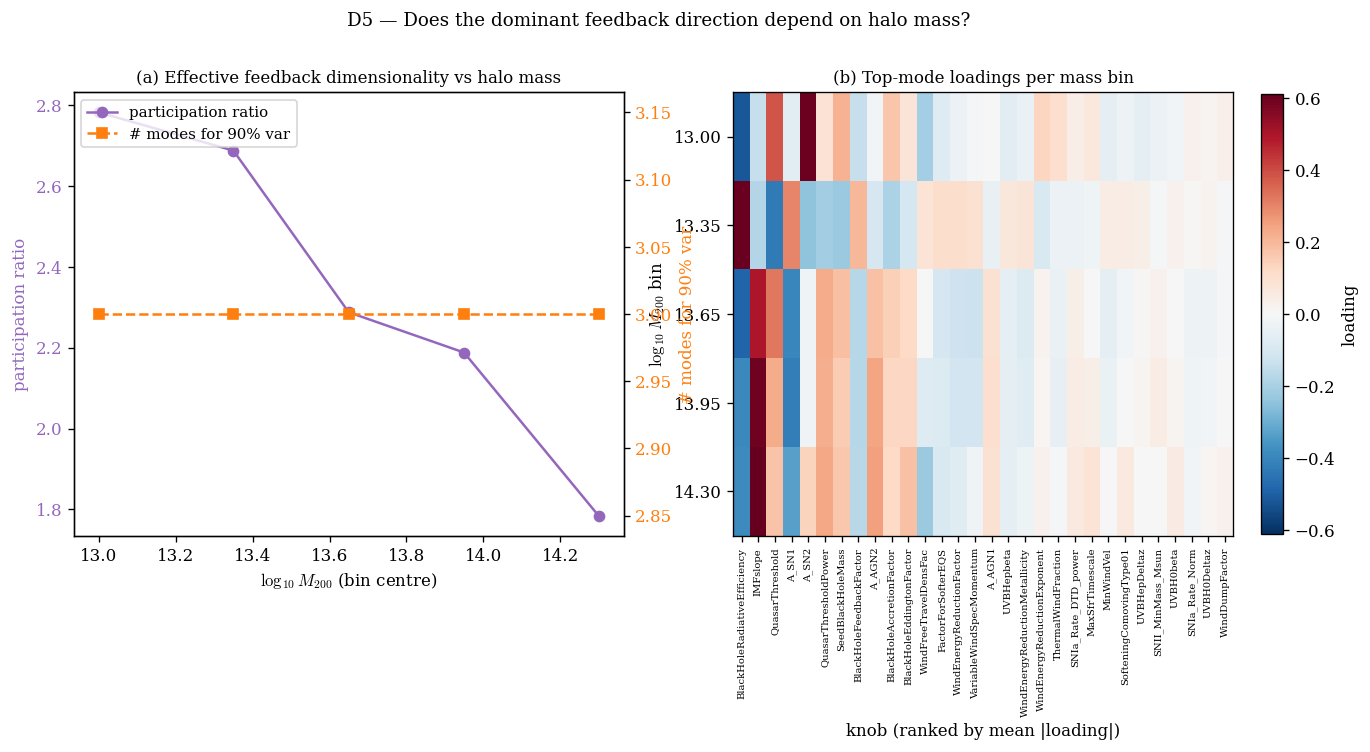

In [4]:
# Per-halo OLS to (column-standardised) Xz -> S_phys (physical-unit response per halo, 30 knobs).
Xz = (design_norm - design_norm.mean(0)) / (design_norm.std(0) + 1e-12)         # (d, 30)
Y  = OBS[..., iSp]                                                              # (d, i)
Yc = Y - np.nanmean(Y, axis=0, keepdims=True)
XtX_inv = np.linalg.pinv(Xz.T @ Xz)
S_phys  = (XtX_inv @ (Xz.T @ np.nan_to_num(Yc))).T                              # (i, 30)
print(f'S_phys shape = {S_phys.shape}   (halos x knobs)')

mass_edges = np.array([12.8, 13.2, 13.5, 13.8, 14.1, 14.5])
mass_ctrs  = 0.5 * (mass_edges[:-1] + mass_edges[1:])
PR_bin, n90_bin, top_mode_bin, n_bin = [], [], [], []
for k in range(len(mass_ctrs)):
    sel = (logM >= mass_edges[k]) & (logM < mass_edges[k + 1])
    if sel.sum() < 20:
        PR_bin.append(np.nan); n90_bin.append(np.nan)
        top_mode_bin.append(np.zeros(len(PLAB))); n_bin.append(int(sel.sum())); continue
    Sk = S_phys[sel] - S_phys[sel].mean(0, keepdims=True)
    _, sv, vt = np.linalg.svd(Sk, full_matrices=False)
    vf = sv ** 2 / np.sum(sv ** 2)
    PR_bin.append(1.0 / np.sum(vf ** 2))
    n90_bin.append(int(np.searchsorted(np.cumsum(vf), 0.90) + 1))
    # sign-align the top mode so that its largest |loading| is positive
    v1 = vt[0].copy()
    if v1[np.argmax(np.abs(v1))] < 0:
        v1 = -v1
    top_mode_bin.append(v1)
    n_bin.append(int(sel.sum()))
PR_bin = np.array(PR_bin); n90_bin = np.array(n90_bin)
top_mode_bin = np.array(top_mode_bin)

print('\nmass bin       N    PR    n90')
for k in range(len(mass_ctrs)):
    print(f'  logM={mass_ctrs[k]:.2f}  {n_bin[k]:4d}  {PR_bin[k]:5.2f}  {n90_bin[k]}')

# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ln1 = ax.plot(mass_ctrs, PR_bin, 'o-', color='tab:purple', label='participation ratio')
ax.set_xlabel(r'$\log_{10} M_{200}$ (bin centre)')
ax.set_ylabel('participation ratio', color='tab:purple')
ax.tick_params(axis='y', labelcolor='tab:purple')
ax2 = ax.twinx()
ln2 = ax2.plot(mass_ctrs, n90_bin, 's--', color='tab:orange', label='# modes for 90% var')
ax2.set_ylabel('# modes for 90% var', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title('(a) Effective feedback dimensionality vs halo mass', fontsize=10)
ax.legend(handles=ln1 + ln2, loc='upper left', fontsize=9)

ax = axes[1]
order = np.argsort(-np.abs(top_mode_bin).mean(0))
vmax = np.max(np.abs(top_mode_bin))
im = ax.imshow(top_mode_bin[:, order], aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(mass_ctrs)))
ax.set_yticklabels([f'{m:.2f}' for m in mass_ctrs])
ax.set_xticks(range(len(PLAB)))
ax.set_xticklabels([PLAB[i] for i in order], rotation=90, fontsize=6)
ax.set_xlabel('knob (ranked by mean |loading|)')
ax.set_ylabel(r'$\log_{10} M_{200}$ bin')
ax.set_title('(b) Top-mode loadings per mass bin', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04, label='loading')

fig.suptitle('D5 — Does the dominant feedback direction depend on halo mass?',
             y=1.02, fontsize=11)
savefig(fig, 'D5_mass_resolved_jacobian'); plt.show()


## D3 — Which observable pairs have feedback-invariant joint distributions?

For each pair of observables $(a, b)$ we compute the per-design Spearman correlation
$\rho_{a,b}(d)$ across all 1111 halos, then look at $\langle\rho\rangle_d$ and ${\rm std}_d(\rho)$
over the 256 designs. **Small ${\rm std}_d(\rho)$ = feedback-invariant relation**, so that
scaling is safe to use in a parameter pipeline; large std flags relations that visibly
deform under feedback.


Pairs ranked by feedback-invariance (low std_d(rho) = invariant):
  Y200       - T           <rho>=+0.956   std_d(rho)=0.0054
  Y200       - P           <rho>=+0.856   std_d(rho)=0.1032
  T          - S           <rho>=+0.677   std_d(rho)=0.1049
  T          - P           <rho>=+0.876   std_d(rho)=0.1089
  Y200       - S           <rho>=+0.715   std_d(rho)=0.1238
  S          - P           <rho>=+0.473   std_d(rho)=0.1472
  S          - supp_prof   <rho>=+0.335   std_d(rho)=0.1643
  S          - f_gas       <rho>=+0.385   std_d(rho)=0.1852
  f_gas      - supp_prof   <rho>=+0.568   std_d(rho)=0.1912
  P          - f_gas       <rho>=+0.634   std_d(rho)=0.1923
  T          - supp_prof   <rho>=+0.491   std_d(rho)=0.2010
  P          - supp_prof   <rho>=+0.532   std_d(rho)=0.2019
  Y200       - supp_prof   <rho>=+0.539   std_d(rho)=0.2084
  T          - f_gas       <rho>=+0.569   std_d(rho)=0.2159
  Y200       - f_gas       <rho>=+0.641   std_d(rho)=0.2412
wrote sobol_cube_figs/D3_invariant

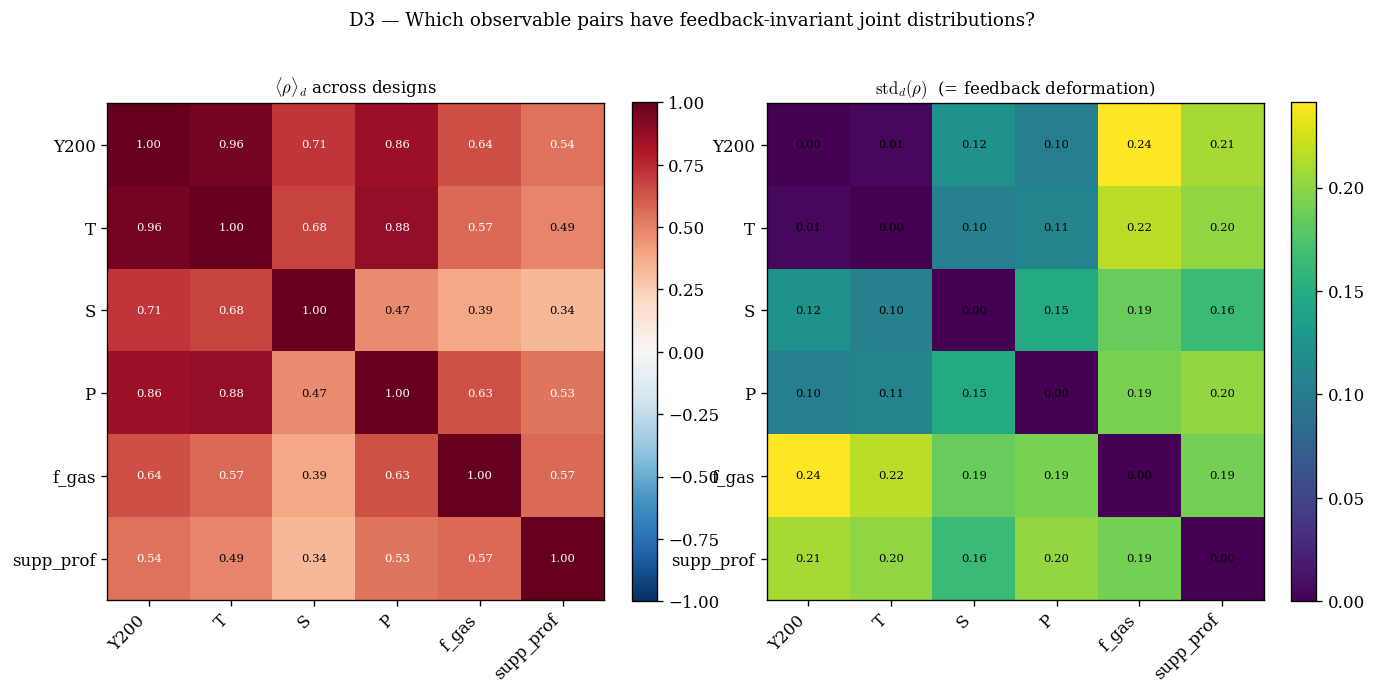

In [5]:
PAIR_NAMES = ['Y200', 'T', 'S', 'P', 'f_gas', 'supp_prof']
PAIR_IDX   = [OBS_NAMES.index(n) for n in PAIR_NAMES]
nP = len(PAIR_NAMES)

rho_mean = np.full((nP, nP), np.nan)
rho_std  = np.full((nP, nP), np.nan)
for a in range(nP):
    for b in range(a + 1, nP):
        rvals = []
        for d in range(n_design):
            x = OBS[d, :, PAIR_IDX[a]]
            y = OBS[d, :, PAIR_IDX[b]]
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() < 10:
                continue
            r = spearmanr(x[m], y[m]).correlation
            if np.isfinite(r):
                rvals.append(r)
        rvals = np.array(rvals)
        rho_mean[a, b] = rho_mean[b, a] = np.nanmean(rvals)
        rho_std [a, b] = rho_std [b, a] = np.nanstd(rvals)
    rho_mean[a, a] = 1.0
    rho_std [a, a] = 0.0

flat = [(PAIR_NAMES[a], PAIR_NAMES[b], rho_mean[a, b], rho_std[a, b])
        for a in range(nP) for b in range(a + 1, nP)]
print('Pairs ranked by feedback-invariance (low std_d(rho) = invariant):')
for n_a, n_b, mu, sd in sorted(flat, key=lambda r: r[3]):
    print(f'  {n_a:10s} - {n_b:10s}  <rho>={mu:+.3f}   std_d(rho)={sd:.4f}')

# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, M, title, cmap, kw in [
    (axes[0], rho_mean, r'$\langle \rho \rangle_d$ across designs',           'RdBu_r', dict(vmin=-1, vmax=1)),
    (axes[1], rho_std,  r'${\rm std}_d(\rho)$  (= feedback deformation)',    'viridis', dict(vmin=0)),
]:
    im = ax.imshow(M, cmap=cmap, **kw)
    ax.set_xticks(range(nP)); ax.set_xticklabels(PAIR_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(nP)); ax.set_yticklabels(PAIR_NAMES)
    for a in range(nP):
        for b in range(nP):
            if np.isnan(M[a, b]):
                continue
            txtcol = 'w' if (cmap == 'RdBu_r' and abs(M[a, b]) > 0.5) else 'k'
            ax.text(b, a, f'{M[a, b]:.2f}', ha='center', va='center',
                    fontsize=7, color=txtcol)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=10)

fig.suptitle('D3 — Which observable pairs have feedback-invariant joint distributions?',
             y=1.02, fontsize=11)
savefig(fig, 'D3_invariant_pairs'); plt.show()


## D2 — Where does the money-plot scatter come from?

The intrinsic scatter $\sigma_{\rm int}\!\approx\!0.086$ around the $Y$–suppression
relation is the headline systematic for tSZ × WL. With CRNs we can decompose the
$(i, d)$ table by classical two-way ANOVA into

$$\sigma^2_{\rm total} \;=\; \sigma^2_{\rm halo} \;+\; \sigma^2_{\rm design} \;+\; \sigma^2_{\rm interaction}$$

and read off the **maximum payoff of pinning down feedback**: if $\sigma^2_{\rm design}$ is
the dominant term, fixing feedback collapses most of the scatter; if it's $\sigma^2_{\rm halo}$,
even a perfect feedback prior leaves an irreducible halo-identity floor.

We do this twice: on raw suppression $S$ and on the **money-plot residual**
$S - (\alpha_d \Delta_{\rm SS} + \beta_d)$ (per-design linear fit removed), which is exactly
the quantity whose scatter we report as $\sigma_{\rm int}$.



raw  S = P_hydro/P_DMO    SS_total=8.995e+02    SS_h+d+res=8.995e+02
    halo        53.0%   sigma = 0.0410
    design      34.2%   sigma = 0.0329
    residual    12.8%   sigma = 0.0201

money-plot residual        SS_total=5.125e+02    SS_h+d+res=5.125e+02
    halo        82.1%   sigma = 0.0385
    design       0.0%   sigma = 0.0000
    residual    17.9%   sigma = 0.0180
wrote sobol_cube_figs/D2_variance_decomp.png


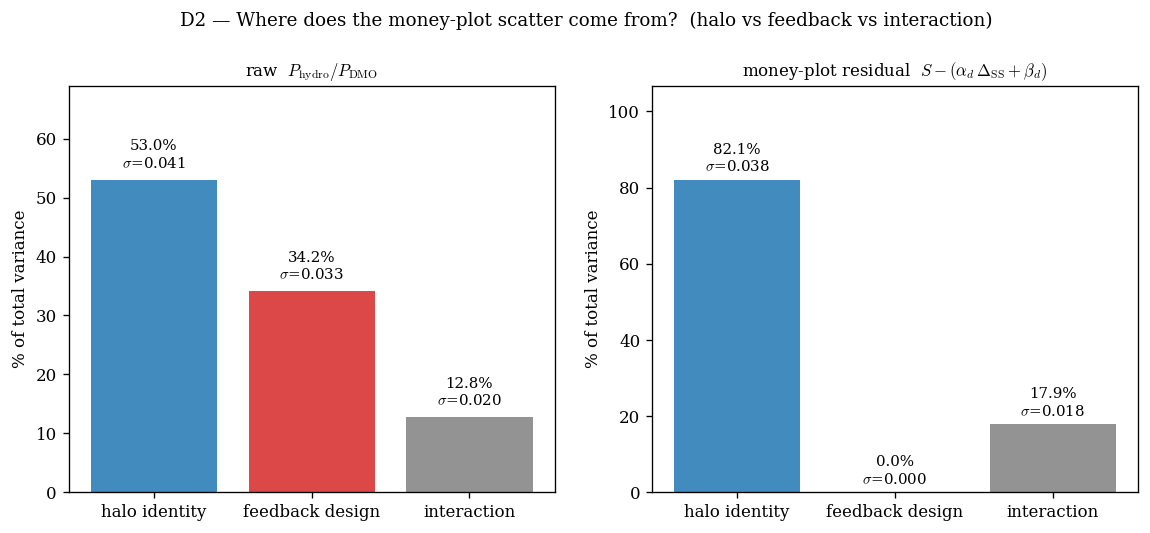

In [6]:
def two_way_decomp(Y):
    """Two-way variance decomposition of Y[d, i] into halo / design / interaction.
    Returns SS_halo, SS_design, SS_residual (sum-of-squares), and the implied sigmas
    (where sigma_x = sqrt(SS_x / N)).  Assumes a near-balanced (d, i) grid.
    """
    Y = np.asarray(Y, dtype=float)
    mask = np.isfinite(Y)
    N    = int(mask.sum())
    mu   = np.nansum(Y) / N
    nD   = mask.sum(axis=1)           # finite halos per design
    nI   = mask.sum(axis=0)           # finite designs per halo
    mu_d = np.where(nD > 0, np.nansum(Y, axis=1) / np.where(nD > 0, nD, 1), np.nan)   # (d,)
    mu_i = np.where(nI > 0, np.nansum(Y, axis=0) / np.where(nI > 0, nI, 1), np.nan)   # (i,)
    # Balanced ANOVA decomposition (approx -- handles small amounts of missing data)
    SS_design = np.nansum(nD * (mu_d - mu) ** 2)
    SS_halo   = np.nansum(nI * (mu_i - mu) ** 2)
    expect    = mu_i[None, :] + mu_d[:, None] - mu
    SS_res    = np.nansum((Y - expect) ** 2)
    SS_total  = np.nansum((Y - mu) ** 2)
    return dict(total=SS_total, halo=SS_halo, design=SS_design, residual=SS_res, N=N)

# (1) raw suppression
D_raw = two_way_decomp(OBS[..., iSp])

# (2) money-plot residual: per design fit S = alpha*DSS + beta, decompose residual
Y_resid = np.full_like(OBS[..., iSp], np.nan)
for d in range(n_design):
    x = DSS[d]; y = OBS[d, :, iSp]
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 5:
        continue
    a, b = np.polyfit(x[m], y[m], 1)
    Y_resid[d, m] = y[m] - (a * x[m] + b)
D_money = two_way_decomp(Y_resid)

def report(name, D):
    SS_parts = D['halo'] + D['design'] + D['residual']
    print(f'\n{name}    SS_total={D["total"]:.3e}    SS_h+d+res={SS_parts:.3e}')
    for k in ('halo', 'design', 'residual'):
        frac = 100 * D[k] / SS_parts
        sig  = np.sqrt(D[k] / D['N'])
        print(f'    {k:9s}  {frac:5.1f}%   sigma = {sig:.4f}')

report('raw  S = P_hydro/P_DMO', D_raw)
report('money-plot residual    ', D_money)

# Figure
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
panels = [
    (axes[0], D_raw,   r'raw  $P_{\rm hydro}/P_{\rm DMO}$'),
    (axes[1], D_money, r'money-plot residual  $S - (\alpha_d\,\Delta_{\rm SS} + \beta_d)$'),
]
labs = ['halo identity', 'feedback design', 'interaction']
cols = ['tab:blue', 'tab:red', '0.5']
for ax, D, ttl in panels:
    T = D['halo'] + D['design'] + D['residual']
    parts = [100 * D['halo'] / T, 100 * D['design'] / T, 100 * D['residual'] / T]
    sigs  = [np.sqrt(D['halo']  / D['N']),
             np.sqrt(D['design']/ D['N']),
             np.sqrt(D['residual']/ D['N'])]
    bars = ax.bar(range(3), parts, color=cols, alpha=0.85)
    for k, (p, s) in enumerate(zip(parts, sigs)):
        ax.text(k, p + 1.5, f'{p:.1f}%\n$\\sigma$={s:.3f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(3)); ax.set_xticklabels(labs)
    ax.set_ylabel('% of total variance')
    ax.set_ylim(0, max(parts) * 1.3)
    ax.set_title(ttl, fontsize=10)

fig.suptitle('D2 — Where does the money-plot scatter come from?  (halo vs feedback vs interaction)',
             y=1.02, fontsize=11)
savefig(fig, 'D2_variance_decomp'); plt.show()
